In [1]:
import pandas as pd
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import plotly.express as px
import yfinance as yf

In [2]:
# Get Apple's stock data from yahoo finance
stock = yf.Ticker("AAPL")
data = stock.history(period="1y")
print(data.head())

                                 Open        High         Low       Close  \
Date                                                                        
2025-04-09 00:00:00-04:00  171.203815  199.739448  171.144078  197.987091   
2025-04-10 00:00:00-04:00  188.249526  193.934739  182.205860  189.593658   
2025-04-11 00:00:00-04:00  185.292419  198.674083  185.252584  197.290115   
2025-04-14 00:00:00-04:00  210.522464  212.015955  200.287075  201.641174   
2025-04-15 00:00:00-04:00  200.984018  202.626852  198.932960  201.262802   

                              Volume  Dividends  Stock Splits  
Date                                                           
2025-04-09 00:00:00-04:00  184395900        0.0           0.0  
2025-04-10 00:00:00-04:00  121880000        0.0           0.0  
2025-04-11 00:00:00-04:00   87435900        0.0           0.0  
2025-04-14 00:00:00-04:00  101352900        0.0           0.0  
2025-04-15 00:00:00-04:00   51343900        0.0           0.0  


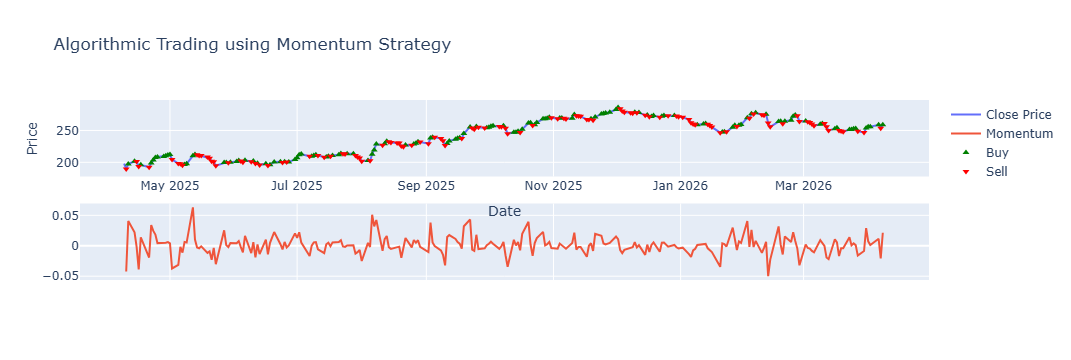

In [3]:
# Calculation of momentum
data['momentum'] = data['Close'].pct_change()

# Creating subplots to show momentum and buying/selling markers
figure = make_subplots(rows=2, cols=1)
figure.add_trace(go.Scatter(x=data.index, 
                         y=data['Close'], 
                         name='Close Price'))
figure.add_trace(go.Scatter(x=data.index, 
                         y=data['momentum'], 
                         name='Momentum', 
                         yaxis='y2'))

# Adding the buy and sell signals
figure.add_trace(go.Scatter(x=data.loc[data['momentum'] > 0].index, 
                         y=data.loc[data['momentum'] > 0]['Close'], 
                         mode='markers', name='Buy', 
                         marker=dict(color='green', symbol='triangle-up')))

figure.add_trace(go.Scatter(x=data.loc[data['momentum'] < 0].index, 
                         y=data.loc[data['momentum'] < 0]['Close'], 
                         mode='markers', name='Sell', 
                         marker=dict(color='red', symbol='triangle-down')))

figure.update_layout(title='Algorithmic Trading using Momentum Strategy',
                  xaxis_title='Date',
                  yaxis_title='Price')
figure.update_yaxes(title="Momentum", secondary_y=True)
figure.show()
